You have houses:
<table>
<tr>
<th>Size (sqft)</th>
<th>Price ($)</th>
</tr>
<tr>
<td>1000</td>
<td>200,000</td>
</tr>
<tr>
<td>1500</td>
<td>280,000</td>
</tr>
<tr>
<td>2000</td>
<td>350,000</td>
</tr>
</table>

Question: If size = 1750, what is price?

Linear Regression draws the BEST STRAIGHT LINE
through all points and reads off the answer.

y = mx + b

- y = price       (what we predict)
- x = size        (what we know)
- m = slope       (how much price changes per sqft)
- b = intercept   (base price when size = 0)

MSE = average of (actual - predicted)²

- Bad line  → predictions far from actual → high MSE
- Best line → predictions close to actual → lowest MSE

Imagine you're blindfolded on a hilly landscape
You want to reach the lowest valley (minimum MSE)

Each step:
1. Feel which direction is downhill
2. Take a small step that direction
3. Repeat until you stop going down

That "feeling downhill" = gradient (slope of MSE)
That "small step" = learning rate

# Gradient descent update rule:
```
m = m - learning_rate * gradient_m
b = b - learning_rate * gradient_b
```
# Gradients:
```
gradient_m = (-2/n) * sum(x * (y - predicted))
gradient_b = (-2/n) * sum(y - predicted)
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class LinearRegressionScratch:

    def __init__(self, learning_rate, n_iterations):

        self.lr =learning_rate
        self.n_iter = n_iterations
        self.m = 0
        self.b = 0

        self.loss_history = []

    def predict(self, X):
        return self.m * X + self.b
         

    def mse(self, y_true, y_pred):
        # return mean of (y_true - y_pred)²
        return np.mean((y_true - y_pred) ** 2)
        

    def fit(self, X, y):
        # gradient descent loop:
        # for each iteration:
        #   → predict
        #   → compute gradients
        #   → update m and b
        #   → store mse history
        n = len(y)

        for _ in range(self.n_iter):
            y_pred = self.predict(X)

            dm = (-2/n) * np.sum(X * (y - y_pred))
            db = (-2/n) * np.sum(y - y_pred)

            # update parameters
            self.m -= self.lr * dm
            self.b -= self.lr * db
            # compute loss
            loss = self.mse(y, y_pred)
            self.loss_history.append(loss)

In [3]:
# Simple dataset
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

model = LinearRegressionScratch(
    learning_rate=0.01,
    n_iterations=1000
)
model.fit(X, y)

print("Slope (m)    :", model.m)
print("Intercept (b):", model.b)
print("Prediction for x=6:", model.predict(6))

Slope (m)    : 0.6176946148762643
Intercept (b): 2.136116825825789
Prediction for x=6: 5.842284515083374


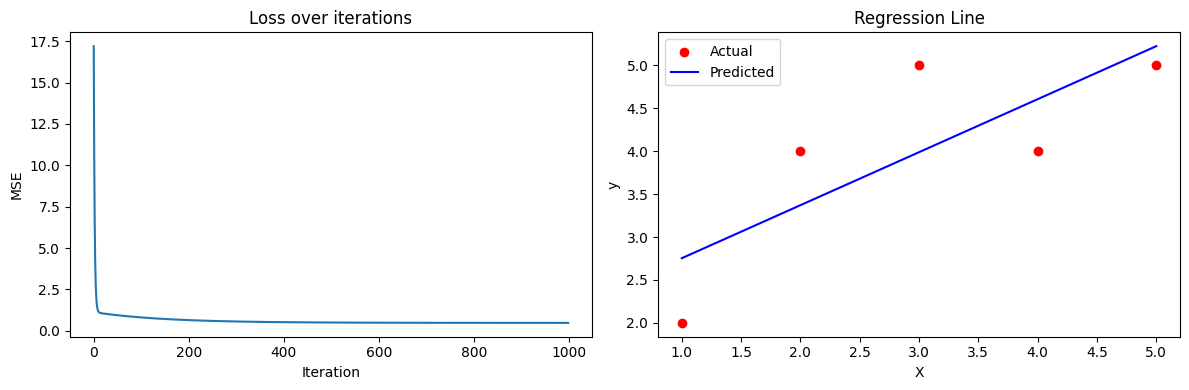

Final MSE    : 0.4807
Slope (m)    : 0.6177
Intercept (b): 2.1361
Predict x=6  : 5.8423


In [4]:
import matplotlib.pyplot as plt

# Plot 1 — Loss curve (did gradient descent work?)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(model.loss_history)
plt.title("Loss over iterations")
plt.xlabel("Iteration")
plt.ylabel("MSE")

# Plot 2 — Regression line vs actual data
plt.subplot(1, 2, 2)
plt.scatter(X, y, color='red', label='Actual')
plt.plot(X, model.predict(X), color='blue', label='Predicted')
plt.title("Regression Line")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Final MSE    : {model.loss_history[-1]:.4f}")
print(f"Slope (m)    : {model.m:.4f}")
print(f"Intercept (b): {model.b:.4f}")
print(f"Predict x=6  : {model.predict(6):.4f}")